# Ridge Regression Project


In [81]:
# import required libreries
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score

In [82]:
df = pd.read_csv("ridge_regression.csv")

In [83]:
df.head()

,feature_1,feature_2_mc,feature_3_mc,feature_4,feature_5,feature_6_mc,feature_7,feature_8,noise_1,noise_2,noise_3,noise_4,noise_5,noise_6,noise_7,noise_8,noise_9,noise_10,target
0,67.548412,136.681113,74.904058,11.160537,394.588486,13.926652,-16.522447,0.421922,0.690173,0.130746,-0.231793,-0.007802,0.457751,1.374572,-0.677779,-0.196643,-1.541875,-0.968554,134.043083
1,10.584888,22.233329,10.508898,17.012526,162.191800,28.139002,-16.290166,0.096716,0.782327,-1.113222,0.568251,-1.514520,-2.619945,-0.606891,-0.915810,0.876012,0.664266,-1.219075,-26.813823
2,87.553621,172.345672,94.751066,2.291219,191.159310,3.137131,-10.688365,0.101001,-0.248490,1.399186,-0.635147,0.721966,0.198365,0.762765,1.332185,-0.560118,-0.474221,-0.387968,251.913937
3,75.621412,152.254209,84.322786,49.476168,355.999904,69.945374,13.714077,0.776000,0.033531,0.253237,-0.315592,0.723632,0.580780,2.321409,0.619968,-0.609403,-0.561798,-0.831581,169.374137
4,92.309283,183.101710,101.285729,12.331375,324.547254,18.179052,15.912915,0.399401,0.663990,3.401817,-0.435820,-0.026117,0.460988,0.140603,-1.233827,-1.272347,-0.319837,0.170221,317.867018


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   feature_1     1000 non-null   float64
 1   feature_2_mc  1000 non-null   float64
 2   feature_3_mc  1000 non-null   float64
 3   feature_4     1000 non-null   float64
 4   feature_5     1000 non-null   float64
 5   feature_6_mc  1000 non-null   float64
 6   feature_7     1000 non-null   float64
 7   feature_8     1000 non-null   float64
 8   noise_1       1000 non-null   float64
 9   noise_2       1000 non-null   float64
 10  noise_3       1000 non-null   float64
 11  noise_4       1000 non-null   float64
 12  noise_5       1000 non-null   float64
 13  noise_6       1000 non-null   float64
 14  noise_7       1000 non-null   float64
 15  noise_8       1000 non-null   float64
 16  noise_9       1000 non-null   float64
 17  noise_10      1000 non-null   float64
 18  target        1000 non-null  

In [85]:
df.isnull().sum()

feature_1       0
feature_2_mc    0
feature_3_mc    0
feature_4       0
feature_5       0
feature_6_mc    0
feature_7       0
feature_8       0
noise_1         0
noise_2         0
noise_3         0
noise_4         0
noise_5         0
noise_6         0
noise_7         0
noise_8         0
noise_9         0
noise_10        0
target          0
dtype: int64

In [86]:
df.shape


(1000, 19)

In [87]:
df.columns

Index(['feature_1', 'feature_2_mc', 'feature_3_mc', 'feature_4', 'feature_5',
       'feature_6_mc', 'feature_7', 'feature_8', 'noise_1', 'noise_2',
       'noise_3', 'noise_4', 'noise_5', 'noise_6', 'noise_7', 'noise_8',
       'noise_9', 'noise_10', 'target'],
      dtype='object')

In [88]:
df.duplicated().sum()

np.int64(0)

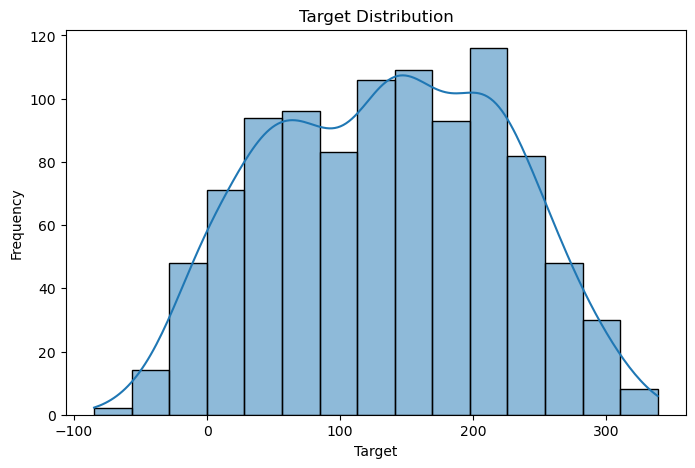

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    df["target"],
    kde=True
)

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Frequency")

plt.show()

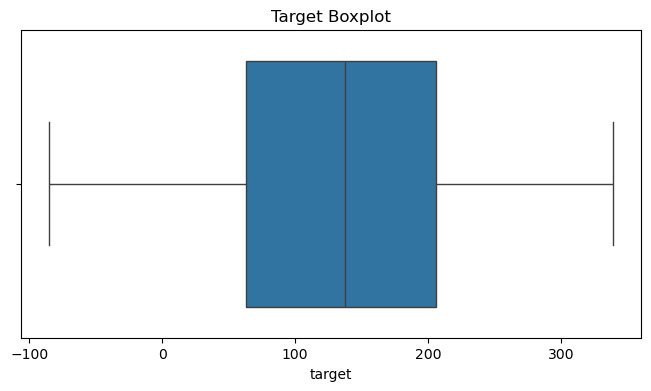

In [91]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["target"]
)

plt.title("Target Boxplot")

plt.show()

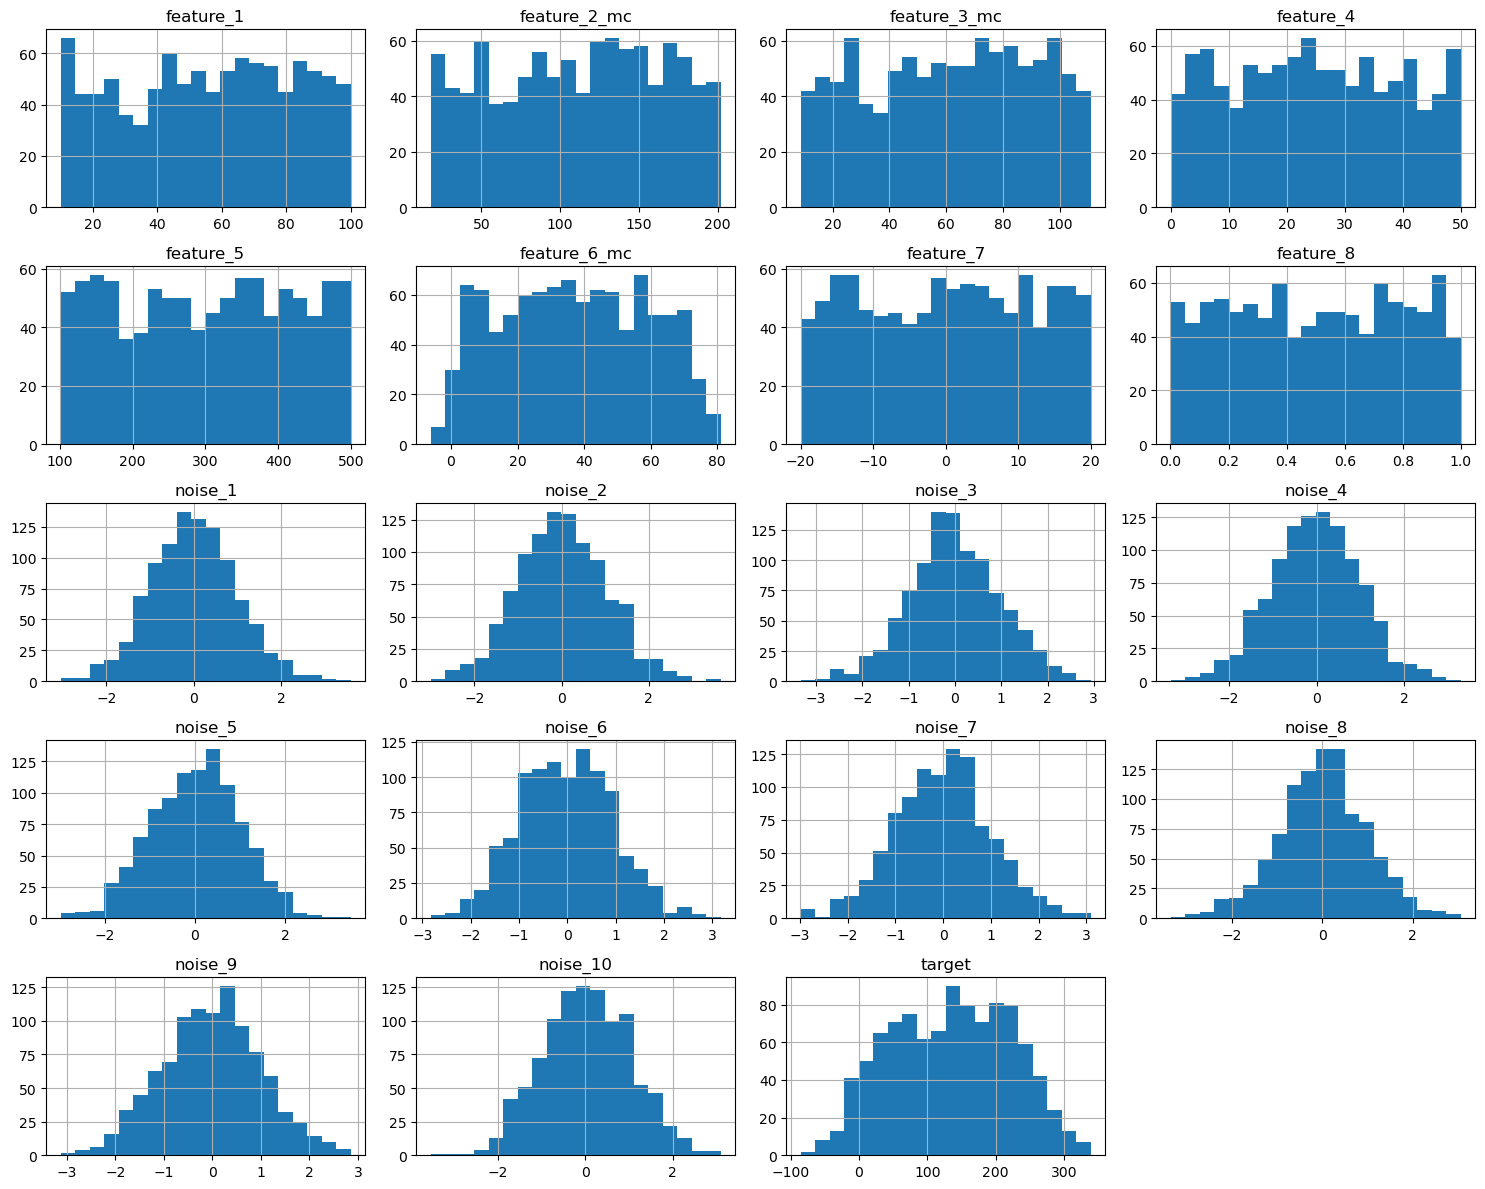

In [93]:
df.hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

In [94]:
for column in df.columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(column, ":", len(outliers))

feature_1 : 0
feature_2_mc : 0
feature_3_mc : 0
feature_4 : 0
feature_5 : 0
feature_6_mc : 0
feature_7 : 0
feature_8 : 0
noise_1 : 11
noise_2 : 6
noise_3 : 13
noise_4 : 8
noise_5 : 5
noise_6 : 2
noise_7 : 15
noise_8 : 19
noise_9 : 5
noise_10 : 5
target : 0


In [ ]:
X = df.drop("target", axis=1)

y = df["target"]


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size =0.20,
    random_state=42

)

In [ ]:
ridge_model = Ridge(alpha=1.0)


In [ ]:
ridge_model.fit(X_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [ ]:
y_pred = ridge_model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

mse = mean_squared_error(y_test,y_pred)
print("MSE:",mse)

r2 = r2_score(y_test,y_pred)
print("r2_score:",r2)

MAE: 12.995685588834089
MSE: 260.65200111310753
r2_score: 0.9674647109654537
